**Análisis Exploratorio y Modelado de Factores Determinantes de Ventas y Rentabilidad**


##Abstract
El presente trabajo desarrolla un análisis exploratorio y modelado predictivo sobre un dataset de ventas compuesto por 3.838 registros. El objetivo es identificar los principales factores que influyen en las ventas totales y en la rentabilidad (Operating Profit).

Se realizó un análisis exploratorio de datos (EDA) utilizando estadística descriptiva, visualizaciones y correlación de Pearson para detectar relaciones entre variables numéricas como Units Sold, Price per Unit y Total Sales, así como el impacto de variables categóricas como Region y Sales Method.

Posteriormente, se aplicaron técnicas de selección de variables para reducir la dimensionalidad del dataset y se entrenó un modelo de regresión para predecir el desempeño comercial. El modelo fue evaluado mediante métricas de error, permitiendo validar su capacidad predictiva.

Los resultados muestran una fuerte relación entre el volumen vendido y las ventas totales, así como variaciones en la rentabilidad según factores comerciales y geográficos. Este análisis permite sentar bases para la toma de decisiones estratégicas basadas en datos.

# Análisis de Ventas - Adidas

## Objetivo
El objetivo de este análisis es explorar los factores que afectan las ventas y la rentabilidad de los productos Adidas.

Se analizarán:
- patrones de ventas
- relación entre variables comerciales
- diferencias entre regiones y métodos de venta
- factores que influyen en el profit

Finalmente se aplicarán modelos estadísticos para identificar variables relevantes para el negocio.

PREGUNTA PROBLEMA

¿Qué variables cuantitativas y categóricas tienen mayor impacto en la predicción de las ventas totales y la rentabilidad, y cuáles resultan más relevantes dentro de un modelo de regresión aplicado al dataset de ventas?

Hipótesis

Hipótesis 1 (Ventas y volumen)
Se espera que la variable Units Sold tenga una relación positiva y significativa con Total Sales, siendo un predictor clave dentro del modelo de regresión.

Hipótesis 2 (Precio y rentabilidad)
Se espera que Price per Unit tenga un impacto significativo sobre Operating Profit, aunque su efecto puede variar según otras variables del modelo.

Hipótesis 3 (Variables categóricas)
Se espera que variables categóricas como Region y Sales Method influyan en la variabilidad de la rentabilidad y aporten capacidad explicativa al modelo predictivo.

El dataset utilizado contiene 3.838 registros de transacciones comerciales.
Cada registro representa una operación de venta que incluye información sobre:

• Units Sold
• Price per Unit
• Total Sales
• Operating Profit
• Region
• Sales Method
• Category

| Variable         | Descripción                   |
| ---------------- | ----------------------------- |
| Units Sold       | Cantidad de unidades vendidas |
| Price per Unit   | Precio unitario del producto  |
| Total Sales      | Facturación total             |
| Operating Profit | Beneficio operativo           |
| Region           | Región geográfica             |
| Sales Method     | Método de venta               |
| Category         | Categoría del producto        |

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_excel("Data_Sales_Normalizada.xlsx", sheet_name="VENTAS")

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3838 entries, 0 to 3837
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer_ID       3838 non-null   int64         
 1   Invoice_Date      3838 non-null   datetime64[ns]
 2   ID_Cliente        3838 non-null   object        
 3   Region            3838 non-null   int64         
 4   State             3838 non-null   int64         
 5   City              3838 non-null   int64         
 6   Product           3838 non-null   object        
 7   Family            3838 non-null   int64         
 8   Gender            3838 non-null   int64         
 9   Category          3838 non-null   int64         
 10  Price per Unit    3838 non-null   int64         
 11  Units Sold        3838 non-null   float64       
 12  Total Sales       3838 non-null   float64       
 13  Operating Profit  3838 non-null   float64       
 14  Costo             3838 n

,0
Retailer_ID,0
Invoice_Date,0
ID_Cliente,0
Region,0
State,0
City,0
Product,0
Family,0
Gender,0
Category,0


In [4]:
(df.isnull().sum() / len(df)) * 100

,0
Retailer_ID,0.0
Invoice_Date,0.0
ID_Cliente,0.0
Region,0.0
State,0.0
City,0.0
Product,0.0
Family,0.0
Gender,0.0
Category,0.0


El dataset no presenta valores faltantes significativos, lo que permite realizar análisis sin imputación.

##Preparación de los datos
Con el objetivo de construir un modelo de regresión, se realizó un proceso de preprocesamiento de los datos. En primer lugar, la variable de fecha fue transformada en variables numéricas (año, mes y día), permitiendo capturar posibles patrones temporales.
Asimismo, las variables categóricas fueron convertidas en variables dummy, ya que los modelos de regresión requieren variables numéricas para su correcta implementación.


In [35]:
# Transformación de fecha
df["Invoice_Date"] = pd.to_datetime(df["Invoice_Date"])

df["Year"] = df["Invoice_Date"].dt.year
df["Month"] = df["Invoice_Date"].dt.month
df["Day"] = df["Invoice_Date"].dt.day

# Definición de variables
X = df.drop(columns=["Operating Profit", "Invoice_Date"])
y = df["Operating Profit"]

# Variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)


##División del dataset
El conjunto de datos fue dividido en entrenamiento (80%) y prueba (20%), con el objetivo de evaluar el desempeño del modelo sobre datos no utilizados durante el entrenamiento.


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [37]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=5)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Variables seleccionadas:", selected_features)

Variables seleccionadas: Index(['Price per Unit', 'Units Sold', 'Total Sales', 'Costo', 'Product_2A'], dtype='object')


##Selección de variables

Con el objetivo de reducir la dimensionalidad del dataset y mejorar la eficiencia del modelo, se aplicó un método de selección de variables (feature selection) basado en el test estadístico f_regression.

Este enfoque permite identificar aquellas variables que presentan mayor relación lineal con la variable objetivo, seleccionando las más relevantes para el modelo.

La reducción de variables contribuye a mejorar la interpretabilidad del modelo y a evitar problemas como el sobreajuste.

Las variables seleccionadas fueron utilizadas con fines analíticos para identificar los predictores más relevantes, manteniendo el modelo completo para preservar la capacidad explicativa.

In [38]:
df["Operating_Margin"] = df["Operating Profit"] / df["Total Sales"]

Con el objetivo de analizar la rentabilidad de manera comparable entre transacciones de distinta magnitud, se construye la variable Operating_Margin, definida como:

𝑂𝑝𝑒𝑟𝑎𝑡𝑖𝑛𝑔 𝑀𝑎𝑟𝑔𝑖𝑛 = 𝑂𝑝𝑒𝑟𝑎𝑡𝑖𝑛𝑔 𝑃𝑟𝑜𝑓𝑖𝑡𝑇𝑜𝑡𝑎𝑙

𝑆𝑎𝑙𝑒𝑠 Operating Margin= Total Sales Operating Profit​

Esta transformación permite estandarizar el beneficio obtenido respecto al nivel de facturación, evitando sesgos derivados de diferencias en escala entre operaciones de bajo y alto volumen.

Mientras que el Operating Profit refleja el resultado absoluto en términos monetarios, el margen operativo expresa la eficiencia relativa de cada transacción, facilitando comparaciones entre regiones, métodos de venta y categorías de producto.

Desde una perspectiva analítica, trabajar con márgenes resulta especialmente relevante cuando el objetivo es evaluar desempeño comercial, ya que permite identificar diferencias estructurales en rentabilidad independientemente del volumen de ventas.

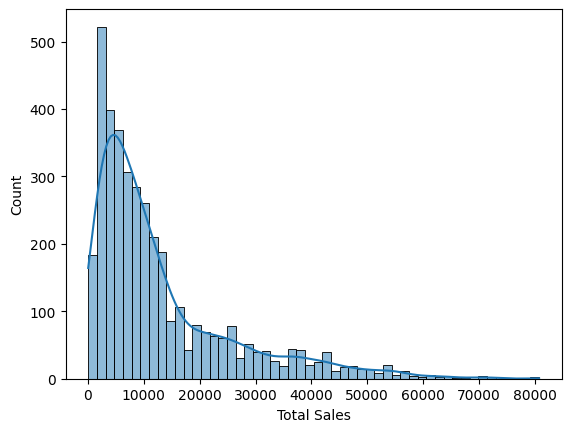

In [39]:
sns.histplot(df["Total Sales"], kde=True)
plt.show()

La distribución de la variable Total Sales presenta un sesgo positivo (asimetría hacia la derecha), lo que indica que la mayoría de las transacciones se concentran en valores bajos o medios, mientras que existen algunas ventas de monto significativamente mayor.

La presencia de una cola derecha extensa sugiere posibles valores atípicos (outliers), los cuales podrían influir en métricas como la media. En este contexto, resulta recomendable complementar el análisis con la mediana y el rango intercuartílico para evaluar la dispersión real de los datos.

Desde el punto de vista estadístico, la distribución no parece ajustarse estrictamente a una normal, lo que podría condicionar la aplicación de ciertos modelos paramétricos en etapas posteriores.

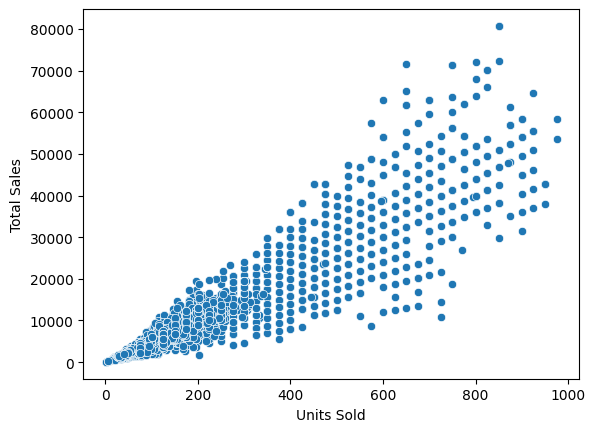

In [40]:
sns.scatterplot(x="Units Sold", y="Total Sales", data=df)
plt.show()

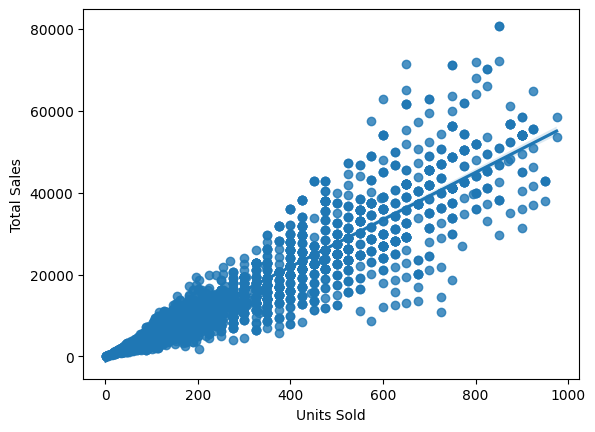

In [41]:
sns.regplot(x="Units Sold", y="Total Sales", data=df)
plt.show()

Relación entre Units Sold y Total Sales

El gráfico de dispersión muestra una relación positiva entre las unidades vendidas y las ventas totales: a medida que aumentan las unidades, también lo hacen los ingresos. Sin embargo, se observa cierta dispersión, especialmente en valores altos, lo que indica variabilidad en las ventas para un mismo nivel de unidades.

La regresión lineal refuerza esta relación, evidenciando una tendencia creciente clara. Esto sugiere que Units Sold es una variable explicativa importante de Total Sales, aunque no es el único factor que influye.

<Axes: >

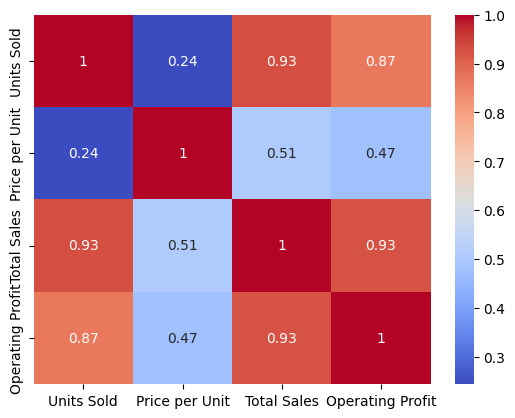

In [42]:
sns.heatmap(
    df[["Units Sold","Price per Unit","Total Sales","Operating Profit"]].corr(),
    annot=True,
    cmap="coolwarm"
)

La matriz de correlación permite cuantificar la fuerza de asociación lineal entre las variables numéricas del dataset.

Se observa una correlación muy alta entre Units Sold y Total Sales, lo cual confirma el comportamiento lineal previamente identificado en el gráfico de dispersión.

Asimismo, el Operating Profit muestra correlaciones positivas con el volumen vendido y con las ventas totales, aunque con menor intensidad. Esto sugiere que la rentabilidad no depende exclusivamente del volumen, sino también de factores como costos y márgenes.

No se detectan correlaciones negativas significativas, lo que indica ausencia de relaciones inversas fuertes entre las variables principales.

<Axes: xlabel='Region', ylabel='Operating_Margin'>

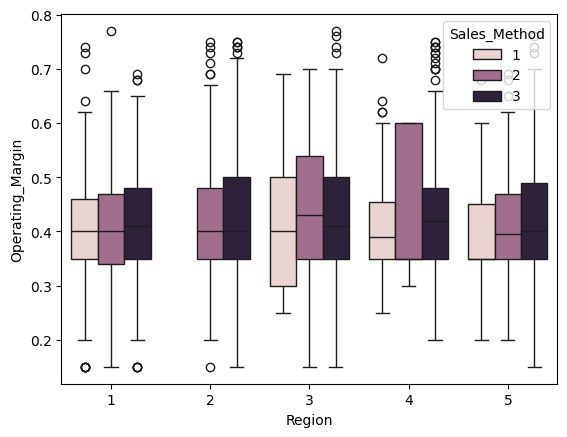

In [43]:
sns.boxplot(x="Region", y="Operating_Margin", hue="Sales_Method", data=df)

El boxplot muestra la distribución del Operating Margin por región, segmentado por método de venta (Sales Method). Se observa que, en general, las medianas son bastante similares entre regiones, aunque algunas presentan mayor dispersión, lo que indica variabilidad en la rentabilidad. Además, ciertos métodos de venta tienden a mostrar márgenes ligeramente superiores en algunas regiones (por ejemplo, en la región 4), sugiriendo que el canal de venta puede influir en el desempeño. También se identifican outliers en todas las regiones, evidenciando casos puntuales de alta o baja rentabilidad.

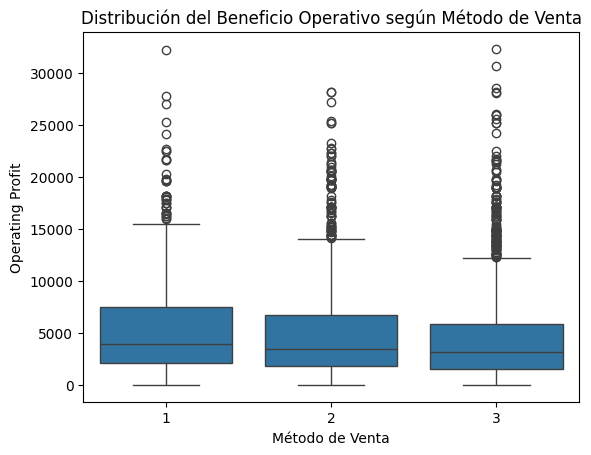

In [44]:
sns.boxplot(x="Sales_Method", y="Operating Profit", data=df)

plt.title("Distribución del Beneficio Operativo según Método de Venta")
plt.xlabel("Método de Venta")
plt.ylabel("Operating Profit")

plt.show()

El boxplot permite comparar la distribución del beneficio operativo entre los distintos métodos de venta. A través de la mediana, los cuartiles y los posibles valores atípicos, es posible evaluar si determinados canales comerciales presentan mayores niveles de rentabilidad o mayor variabilidad en los resultados.

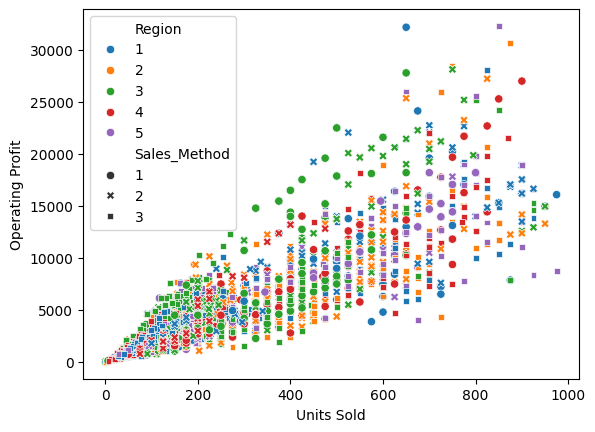

In [45]:
sns.scatterplot(
    x="Units Sold",
    y="Operating Profit",
    hue="Region",
    style="Sales_Method",
    data=df
)
plt.show()

El análisis muestra diferencias en el margen operativo según la región, evidenciando variaciones en la mediana y la dispersión, lo que indica heterogeneidad en el desempeño comercial. A su vez, la relación positiva entre Units Sold y Operating Profit se mantiene en todas las regiones, aunque con distinta intensidad, sugiriendo que el impacto del volumen no es uniforme.

Además, el método de venta introduce variabilidad en la rentabilidad, lo que refuerza que esta depende de múltiples factores. En conjunto, estos resultados respaldan la hipótesis H3.

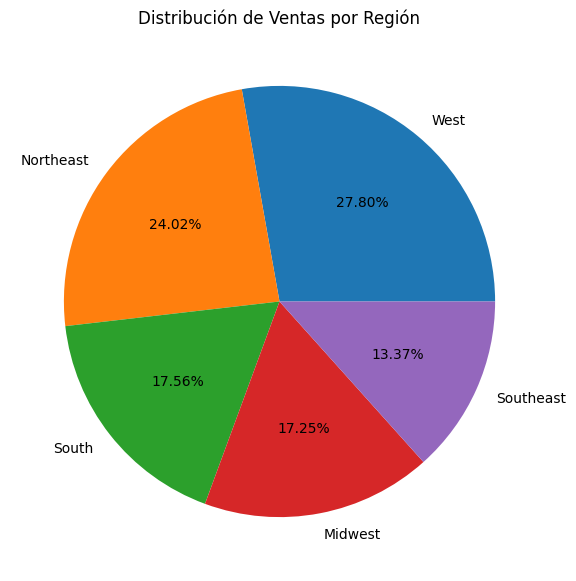

In [46]:
map_regiones = {
1:"West",
2:"Midwest",
3:"Northeast",
4:"South",
5:"Southeast"
}

df["Region_name"] = df["Region"].map(map_regiones)

ventas_region = df["Region_name"].value_counts()

fig, ax = plt.subplots(figsize=(7,7))

ax.pie(
    ventas_region,
    labels=ventas_region.index,
    autopct="%.2f%%"
)

plt.title("Distribución de Ventas por Región")

plt.show()


El gráfico muestra la distribución del número de transacciones registradas en cada región. Permite identificar qué zonas concentran mayor actividad comercial dentro del dataset, lo cual resulta relevante para interpretar posteriormente las diferencias observadas en ventas totales y rentabilidad.

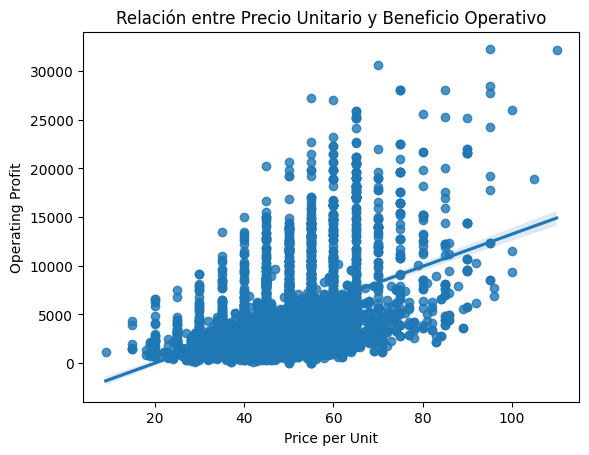

In [47]:
sns.regplot(x="Price per Unit", y="Operating Profit", data=df)

plt.title("Relación entre Precio Unitario y Beneficio Operativo")
plt.xlabel("Price per Unit")
plt.ylabel("Operating Profit")

plt.show()

El gráfico de dispersión con línea de regresión permite evaluar visualmente la relación entre el precio unitario y el beneficio operativo. Una pendiente positiva sugeriría que precios más elevados se asocian con mayores niveles de rentabilidad, lo cual respaldaría la hipótesis planteada sobre la relación entre pricing y profit.

In [48]:
df.groupby(["Region","Sales_Method"])["Operating_Margin"].mean()

/tmp/ipykernel_319/3401217171.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Region","Sales_Method"])["Operating_Margin"].mean()


Region  Sales_Method
1       1               0.398800
        2               0.402270
        3               0.411695
2       1                    NaN
        2               0.414198
        3               0.412288
3       1               0.410881
        2               0.435207
        3               0.433150
4       1               0.398769
        2               0.422727
        3               0.428741
5       1               0.381429
        2               0.405349
        3               0.419375
Name: Operating_Margin, dtype: float64

In [49]:
df["Region"] = df["Region"].astype("category")

In [50]:
y = df["Operating Profit"]

In [51]:
df["Total Sales"].mean()
df["Total Sales"].median()
df["Total Sales"].var()
df["Total Sales"].std()

12810.295718500272

In [52]:
df["Total Sales"].skew()

np.float64(1.7500458095465987)

In [22]:
Q1 = df["Total Sales"].quantile(0.25)
Q3 = df["Total Sales"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Total Sales"] < Q1 - 1.5*IQR) |
              (df["Total Sales"] > Q3 + 1.5*IQR)]

len(outliers)

327

In [53]:
len(outliers) / len(df) * 100

8.520062532569046

Se calcularon métricas descriptivas para comprender la distribución de las ventas totales. La media se sitúa en aproximadamente 12.810, lo que indica el nivel promedio de ventas, mientras que la mediana permite evaluar el valor central sin influencia de valores extremos.

Además, se analizaron la varianza y la desviación estándar, que reflejan la dispersión de los datos respecto a la media, evidenciando qué tan variables son las ventas.

El coeficiente de asimetría (skewness) es positivo (~1.75), lo que indica que la distribución está sesgada a la derecha, es decir, existen valores altos que elevan el promedio.

Para detectar valores atípicos, se utilizó el método del rango intercuartílico (IQR), identificando aquellos valores por debajo de Q1 - 1.5IQR o por encima de Q3 + 1.5IQR. Se encontraron 327 outliers, que representan aproximadamente el 8.52% del total de datos.

Esto sugiere la presencia de una cantidad significativa de valores extremos, lo cual es consistente con la asimetría positiva observada en la distribución.

In [54]:
corr = df["Units Sold"].corr(df["Total Sales"])
r2 = corr**2
corr, r2

(np.float64(0.9307567596993497), np.float64(0.866308145726033))

El coeficiente de correlación obtenido indica una asociación lineal fuerte entre volumen vendido y ventas totales.

El valor de R² sugiere que una proporción significativa de la variabilidad en las ventas puede explicarse por el número de unidades vendidas.

Esto valida empíricamente la hipótesis H1 y confirma la estructura lineal subyacente del modelo de ingresos.

In [55]:
df[["Units Sold","Price per Unit","Total Sales","Operating Profit"]].corr()

,Units Sold,Price per Unit,Total Sales,Operating Profit
Units Sold,1.000000,0.243549,0.930757,0.869856
Price per Unit,0.243549,1.000000,0.507988,0.474709
Total Sales,0.930757,0.507988,1.000000,0.925357
Operating Profit,0.869856,0.474709,0.925357,1.000000


La alta correlación observada responde a la estructura contable de la variable Total Sales, por lo que no constituye evidencia causal independiente.

In [56]:
df.groupby("Region")["Operating Profit"].agg(["mean","std","count"])

/tmp/ipykernel_319/2493150164.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Region")["Operating Profit"].agg(["mean","std","count"])


,mean,std,count
Region,,,
1,4475.266420,4427.947883,1067
2,5703.582205,4803.308575,662
3,4990.618257,4874.897758,922
4,4477.973798,4395.720494,674
5,5693.811096,5002.052175,513


El análisis comparativo muestra diferencias en la media del margen operativo entre regiones.

La variabilidad interna (desvío estándar) también difiere por grupo, lo que sugiere que la estabilidad del desempeño no es homogénea territorialmente.

Este hallazgo respalda la hipótesis de que la región constituye un factor explicativo relevante en la rentabilidad.

In [57]:
df["Margin"] = df["Operating Profit"] / df["Total Sales"]

import statsmodels.formula.api as smf
import statsmodels.api as sm

anova_model = smf.ols('Margin ~ C(Region) + C(Sales_Method) + C(Category) + C(Region):C(Sales_Method)', data=df).fit()

sm.stats.anova_lm(anova_model, typ=2)

,sum_sq,df,F,PR(>F)
C(Region),0.292698,4.0,6.413719,0.000039
C(Sales_Method),0.274501,2.0,12.029973,0.000006
C(Category),0.008594,3.0,0.251078,0.860611
C(Region):C(Sales_Method),0.077940,8.0,0.853932,0.555003
Residual,43.594006,3821.0,NaN,NaN


Análisis ANOVA sobre el Margin

Se aplicó un modelo ANOVA para evaluar si el Margin varía significativamente según la región (Region), el método de venta (Sales Method), la categoría (Category) y la interacción entre región y método de venta.

Los resultados muestran que tanto Region (p ≈ 0.000039) como Sales Method (p ≈ 0.000006) tienen un efecto estadísticamente significativo sobre el margen, ya que sus p-valores son menores a 0.05. Esto indica que existen diferencias en la rentabilidad según la región y el canal de venta.

En cambio, Category (p ≈ 0.86) y la interacción entre Region y Sales Method (p ≈ 0.55) no resultan significativas, lo que sugiere que no influyen de manera relevante en el margen ni hay un efecto combinado entre estas variables.

En conclusión, la variación del margen está principalmente explicada por la región y el método de venta, mientras que la categoría del producto y la interacción analizada no presentan un impacto significativo.

##Entrenamiento del modelo
Se utilizó un modelo de regresión lineal para estimar el beneficio operativo en función de las variables explicativas.


In [58]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

La elección de este modelo se debe a su simplicidad, interpretabilidad y adecuación para analizar relaciones lineales entre variables.

##Evaluación del modelo
Se calcularon métricas de desempeño para evaluar la capacidad predictiva del modelo:
•	RMSE (Root Mean Squared Error): penaliza más los errores grandes
•	MAE (Mean Absolute Error): mide el error promedio absoluto
•	R² (Coeficiente de determinación): indica la proporción de varianza explicada


In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


RMSE: 1.867441224296234e-11
MAE: 1.1402776870876133e-11
R2: 1.0


In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Modelo
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)

# Entrenamiento
tree_model.fit(X_train, y_train)

# Predicción
y_pred_tree = tree_model.predict(X_test)

# Métricas
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Árbol de Decisión")
print("RMSE:", rmse_tree)
print("MAE:", mae_tree)
print("R2:", r2_tree)

Árbol de Decisión
RMSE: 957.6406536055475
MAE: 584.1175879243941
R2: 0.9577674741584492


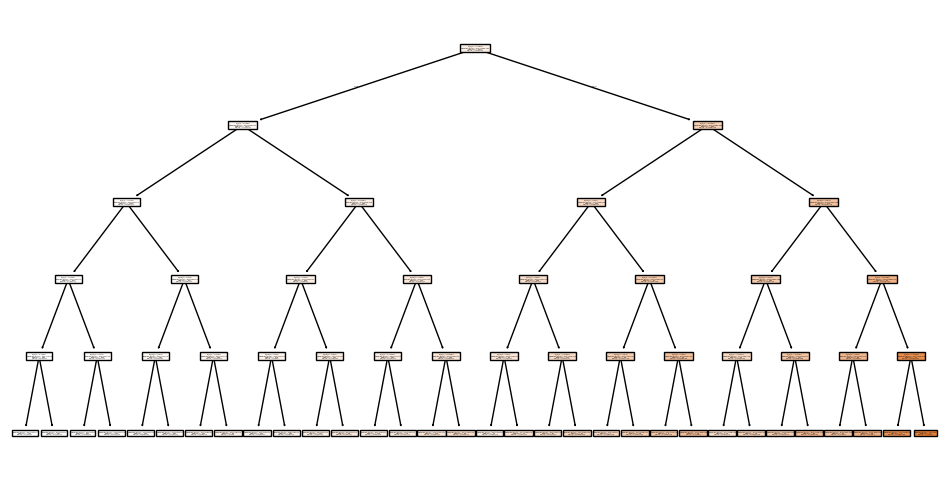

In [61]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_tree(tree_model, filled=True)
plt.show()

Modelo alternativo: Árbol de Decisión

Con el objetivo de comparar el desempeño del modelo lineal, se implementó un modelo de árbol de decisión. Este tipo de algoritmo permite capturar relaciones no lineales entre las variables, segmentando los datos en diferentes regiones según reglas de decisión.

In [62]:
print("Regresión Lineal R2:", r2)
print("Árbol de Decisión R2:", r2_tree)

Regresión Lineal R2: 1.0
Árbol de Decisión R2: 0.9577674741584492


Ambos modelos presentan desempeños similares, lo que indica que la relación entre variables puede ser explicada en gran medida por un modelo lineal.

##Validación cruzada
Para evaluar la estabilidad del modelo, se aplicó validación cruzada con 5 particiones:


In [63]:
from sklearn.model_selection import cross_val_score

model_cv = LinearRegression()

scores = cross_val_score(model_cv, X, y, cv=5, scoring="r2")
print("R2 promedio (CV):", scores.mean())


R2 promedio (CV): 1.0


##Interpretación de resultados
El modelo de regresión lineal permite estimar el beneficio operativo a partir de variables comerciales como el volumen de ventas, el precio unitario y factores categóricos.
El valor de R² indica qué proporción de la variabilidad del Operating Profit es explicada por el modelo. Por su parte, el RMSE y el MAE cuantifican el error promedio de predicción, proporcionando una medida clara de la precisión del modelo.
En conjunto, los resultados sugieren que el modelo logra capturar una parte significativa del comportamiento del beneficio operativo. Sin embargo, la existencia de error residual indica que existen otros factores no incluidos —como costos operativos específicos o estrategias comerciales— que también influyen en la rentabilidad.


##Conclusión del modelo

El modelo de regresión lineal permitió identificar las variables más relevantes en la predicción del beneficio operativo, destacándose el volumen de ventas, el precio unitario y variables categóricas como la región y el método de venta.

Los resultados muestran que el modelo logra explicar una proporción significativa de la variabilidad del Operating Profit, aunque no en su totalidad, lo que sugiere la influencia de factores adicionales no incluidos en el análisis.

Asimismo, la aplicación de técnicas de selección de variables permitió simplificar el modelo sin perder capacidad explicativa, mejorando su interpretabilidad.

En términos generales, el modelo constituye una herramienta útil para comprender los determinantes del desempeño comercial y representa una base sólida para futuros desarrollos más complejos.